## Inspect self_train.py Results

In [38]:
import pickle
import glob
import os
import matplotlib.pyplot as plt

import json
import argparse
import cv2
import numpy as np
import torch

import re

from networks.corenet import CoRE_Net
from networks.framework import MyFrame
from utils.loss import dice_bce_loss

In [39]:
def get_latest_result_dir(results_root='./results/selftrain'):
    candidates = glob.glob(os.path.join(results_root, '*'))
    ts_re = re.compile(r'^(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})-')

    dated = []
    for path in candidates:
        m = ts_re.match(os.path.basename(path))
        if m:
            dated.append((m.group(1), path))

    if not dated:
        raise FileNotFoundError(f'No matching result folders found in {results_root}')

    return max(dated)[1]

In [40]:
exp_dir = get_latest_result_dir(results_root='./results/selftrain/')
#exp_dir = './results/selftrain/2026-10-05_16-56-00-ltLSE6Cb'
exp_dir

'./results/selftrain/2026-10-06_13-31-40-dC56FZO6'

In [41]:
def to_scalar(x):
    return x.item() if hasattr(x, 'item') else x

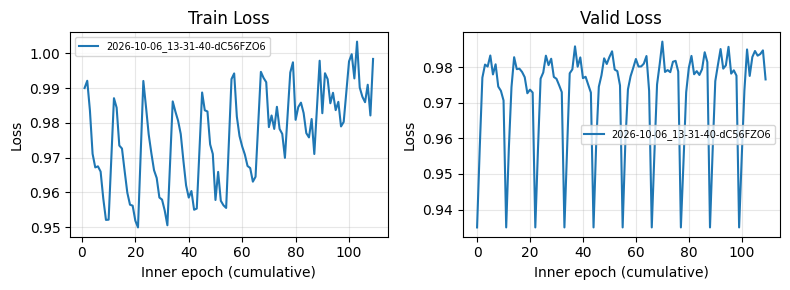

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

with open(os.path.join(exp_dir, 'result.pkl'), 'rb') as f:
    record = pickle.load(f)

label = os.path.basename(exp_dir)
n_inner = 10  # --total-inner-epoch

def flatten(mode):
    xs, ys = [], []
    for o in sorted(record[mode]):
        for i in sorted(record[mode][o]):
            xs.append(o * (n_inner + 1) + i + 1)
            ys.append(to_scalar(record[mode][o][i][f'{mode}_loss']))
    return xs, ys

axes[0].plot(*flatten('train'), label=label)
axes[1].plot(*flatten('valid'), label=label)

axes[0].set_title('Train Loss')
axes[1].set_title('Valid Loss')
for ax in axes:
    ax.set_xlabel('Inner epoch (cumulative)')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:
# rebuild args from the saved config
with open(f'{exp_dir}/config.json') as f:
    cfg = json.load(f)

args = argparse.Namespace(**cfg)
args.t_total = 1

# build model and load best validation weights
solver = MyFrame(CoRE_Net, dice_bce_loss, args, evalmode=True)
solver.load(f'{exp_dir}/weights/train.th')
solver.eval()

valid_losses = [((o, i), record['valid'][o][i]['valid_loss'].item())
                for o in sorted(record['valid'])
                for i in sorted(record['valid'][o])
               if i >= 0]
(best_outer, best_inner), best_loss = min(valid_losses, key=lambda x: x[1])
print(best_outer, best_inner, best_loss)

7 0 0.9535889625549316


In [44]:
import importlib
import utils.data_selftrain as ds
importlib.reload(ds)

from utils.data_selftrain import ImageFolder   # re-bind the name to the new class

In [46]:
testset = ImageFolder(root_path='/masc_shared/ag_nauss/projects/phytoakmeter/IEE/vein_segmentation_training_data',
                      datasets='scan_and_photo_labels',
                      mode='test',
                      is_random=False)

img, mask, b_map = testset[0]
print('GT fg fraction:', mask.mean().item())          # veins should be ~0.05-0.2

solver.set_input(img[None].cuda(), mask[None], b_map[None])
_, pred, _ = solver.test()
print('pred min/max/mean:', pred.min().item(), pred.max().item(), pred.mean().item())

I1006 13:38:42.202319 631494 data_selftrain.py:257] mode: test
I1006 13:38:42.203083 631494 data_selftrain.py:280] CEE_DE_3M_P25071015300010_104_105_15D_LM_2_14, 0.0
I1006 13:38:42.203722 631494 data_selftrain.py:280] 104_105_15D_LM_1_leaf_08, 1.0
I1006 13:38:42.204163 631494 data_selftrain.py:280] CEE_DE_3M_P25071019000010_104_105_15D_LM_1_84, 2.0
I1006 13:38:42.204622 631494 data_selftrain.py:280] CEE_DE_3G_P25070611295910_8_9_2A_M_1_07, 3.0
I1006 13:38:42.204943 631494 data_selftrain.py:280] CEE_DE_3G_P25070317295910_8_9_2A_M_1_03, 4.0
I1006 13:38:42.205263 631494 data_selftrain.py:280] CEE_DE_3M_P25071017295910_104_105_15D_LM_3_09, 5.0
I1006 13:38:42.205564 631494 data_selftrain.py:280] CEE_DE_3G_P25070512595910_8_9_2A_M_1_02, 6.0
I1006 13:38:42.205902 631494 data_selftrain.py:280] CEE_DE_3G_P25070315000110_8_9_2A_M_1_03, 7.0
I1006 13:38:42.206250 631494 data_selftrain.py:280] 135_136_20A_M_1_leaf_07, 8.0
I1006 13:38:42.206568 631494 data_selftrain.py:280] CEE_DE_3G_P25070616295910

GT fg fraction: 0.019212372601032257
pred min/max/mean: 3.734786091502684e-10 0.9993021488189697 0.5816775560379028


In [47]:
def predict_mask(solver, img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_norm = img.astype(np.float32) / 255.0 * 3.2 - 1.6   # same normalization as test_one_img_from_path
    img_t = torch.from_numpy(img_norm).permute(2, 0, 1).unsqueeze(0).cuda()  # (1, C, H, W)

    with torch.no_grad():
        result = solver.net.forward(img_t)          # dict, since net is in eval mode
        pred = result['mask_logits'].sigmoid()        # apply sigmoid — logits aren't probabilities

    mask = pred.squeeze().cpu().numpy()
    mask_bin = (mask > 0.8).astype(np.uint8)
    return img, mask, mask_bin

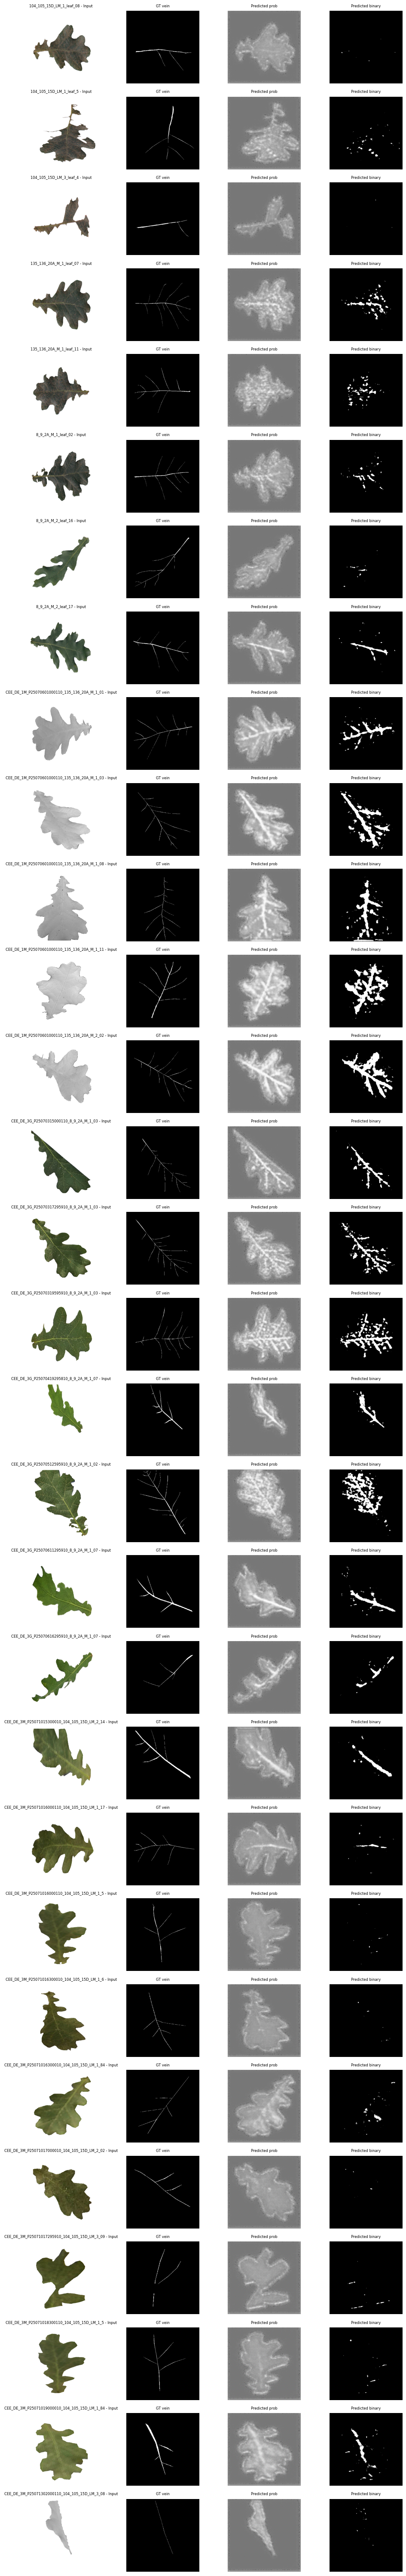

In [48]:
leaf_dirs = sorted(glob.glob(os.path.join(args.data_root, args.dataset, 'test/', '*')))

fig, axes = plt.subplots(len(leaf_dirs), 4, figsize=(10, 2 * len(leaf_dirs)))

for i, leaf_dir in enumerate(leaf_dirs):
    leaf_id = os.path.basename(leaf_dir)
    leaf_path = os.path.join(leaf_dir, 'leaf.png')
    vein_path = os.path.join(leaf_dir, 'vein.png')
    outline_path = os.path.join(leaf_dir, 'outline.png')

    orig, prob_mask, bin_mask = predict_mask(solver, leaf_path)
    gt_vein = cv2.imread(vein_path, cv2.IMREAD_GRAYSCALE)

    axes[i, 0].imshow(orig); axes[i, 0].set_title(f'{leaf_id} - Input', fontsize=6); axes[i, 0].axis('off')
    axes[i, 1].imshow(gt_vein, cmap='gray'); axes[i, 1].set_title('GT vein', fontsize=6); axes[i, 1].axis('off')
    axes[i, 2].imshow(prob_mask, cmap='gray', vmin=0, vmax=1); axes[i, 2].set_title('Predicted prob', fontsize=6); axes[i, 2].axis('off')
    axes[i, 3].imshow(bin_mask, cmap='gray'); axes[i, 3].set_title('Predicted binary', fontsize=6); axes[i, 3].axis('off')

plt.tight_layout()
#-plt.savefig('inference_results.png', dpi=150)
plt.show()

In [49]:
import torch
from torch.utils.data import DataLoader
from utils.metrics import calculate_IoU_Dice
import glog as log

In [50]:
solver.load('/home/justs/detection_segmentation/IEE/vein_segmentation/results/pretrain/ds_32-lr_1e-06-2026-09-29_11-17-05-nJbIJJlf/weights/valid.th')
solver.eval()
loader = DataLoader(testset, batch_size=8, shuffle=False)

results, gts = [], []
with torch.no_grad():
    for img, mask, b_map in loader:
        solver.set_input(img.cuda(), mask, b_map)
        out = solver.test()        # 2 or 3 values depending on pointmode
        pred = out[1]
        for p, m in zip(pred, mask):
            results.append(p.squeeze().cpu().numpy())
            gts.append(m.squeeze().cpu().numpy())

print(calculate_IoU_Dice(results, gts, logger=log))

({'mIoU': np.float64(0.3931), 'mAcc': np.float64(0.8706999999999999), 'aAcc': np.float64(0.7575)}, {'mDice': np.float64(0.46009999999999995), 'mAcc': np.float64(0.8706999999999999), 'aAcc': np.float64(0.7575)})


In [51]:
th = {'high': 0.9, 'low': 0.5}
pred_results, b_maps, _ = my_infer.infer_point(args, testset, solver, th, 0, 'test')

preds = [(p > 0).astype(np.float32) for p in pred_results]
gts = [testset[i][1].squeeze().numpy() for i in range(len(testset))]
print(calculate_IoU_Dice(preds, gts, logger=log)[1]['mDice'])   # expect about 0.61
print('pseudo fg:', np.mean([p.mean() for p in preds]), 'GT fg:', np.mean([g.mean() for g in gts]))

NameError: name 'my_infer' is not defined

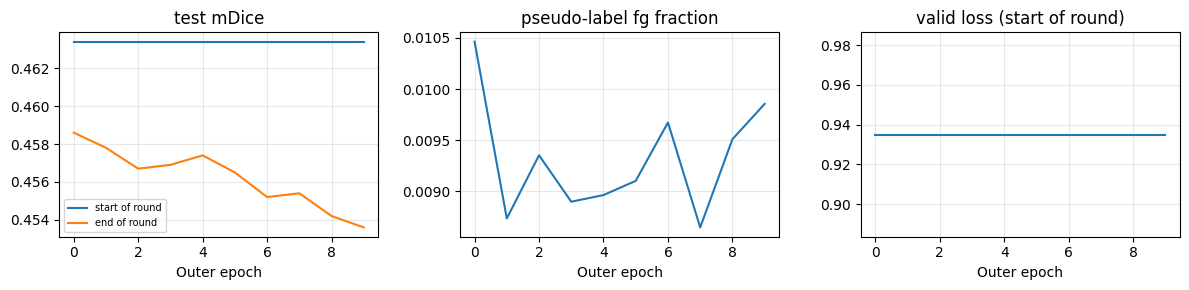

best mDice round: 0
best valid-loss round: 0


In [52]:
import pickle, os, numpy as np
import matplotlib.pyplot as plt

with open(os.path.join(exp_dir, 'result.pkl'), 'rb') as f:
    record = pickle.load(f)

outer = sorted(record['test'])
dice_start = [record['test'][o][-1]['mDice'] for o in outer]                      # model that made this round's labels
dice_end   = [record['test'][o][max(record['test'][o])]['mDice'] for o in outer]  # after the round's training
vloss      = [record['valid'][o][-1]['valid_loss'].item() for o in outer]
fg         = [record['pseudo_fg'][o] for o in outer]

fig, ax = plt.subplots(1, 3, figsize=(12, 3))
ax[0].plot(outer, dice_start, label='start of round')
ax[0].plot(outer, dice_end, label='end of round')
ax[0].set_title('test mDice'); ax[0].legend(fontsize=7)
ax[1].plot(outer, fg); ax[1].set_title('pseudo-label fg fraction')
ax[2].plot(outer, vloss); ax[2].set_title('valid loss (start of round)')
for a in ax:
    a.set_xlabel('Outer epoch'); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('best mDice round:', outer[int(np.argmax(dice_start))])
print('best valid-loss round:', outer[int(np.argmin(vloss))])

In [54]:
print([round(record['test'][0][i]['mDice'], 3) for i in sorted(record['test'][0])])

[0.463, 0.456, 0.455, 0.455, 0.456, 0.457, 0.457, 0.457, 0.457, 0.457, 0.459]
